# ScLNet Adapted for Keratitis AS-OCT Segmentation

**Project:** Automated Segmentation of Corneal Structures in Keratitis AS-OCT Images  
**Model:** ScLNet (Cao et al., Heliyon 2024) — adapted from scleral lens OCT to keratitis AS-OCT  
**Dataset:** AIDK — An AS-OCT Image Dataset for Deep Learning-Enabled Segmentation (Sun et al., Scientific Data 2024)  

---

## Overview

This notebook implements the **ScLNet** multi-task segmentation network in PyTorch and adapts it
for the **AIDK keratitis AS-OCT dataset**. The original ScLNet was designed to segment scleral lens,
tear fluid reservoir, and cornea from OCT images. Here we repurpose it to segment **cornea** and
**keratitis lesion** (and optionally **iris** for full-frame images).

### Key Architectural Components (from the paper)
1. **ResNet-34 backbone encoder** with feature subtraction to emphasise boundaries  
2. **Multi-scale input pyramid** (full, ½, ¼, ⅛ resolutions)  
3. **Dense Atrous Convolution (DAC)** blocks for multi-scale context  
4. **Dual-task decoder** — segmentation masks + boundary prediction  
5. **Weighted log-Dice loss** (0.4 × boundary + 0.6 × segmentation)

## 0 — Install & Import Dependencies

In [1]:
# Uncomment and run if packages are not yet installed
# !pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
# !pip install albumentations opencv-python-headless scikit-learn scipy matplotlib tqdm

In [2]:
import os
import json
import glob
import random
import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from collections import OrderedDict

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

from sklearn.model_selection import train_test_split
from scipy.spatial.distance import directed_hausdorff
from tqdm.auto import tqdm

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 1 — Configuration

Set your dataset paths and training hyperparameters below.

In [3]:
# ============================================================
# >>>  SET YOUR DATASET PATHS HERE  <<<
# ============================================================

# Root folder where the AIDK dataset was extracted.
# Expected structure:
#   DATASET_ROOT/
#     Partial-frame_Dataset/
#       Original_AS-OCT_Images/   (1.bmp, 2.bmp, ... 400.bmp)
#       Experts_Annotations/      (1.json, 2.json, ... 400.json)
#     Full-frame_Dataset/
#       Original_AS-OCT_Images/   (1.bmp, 2.bmp, ... 768.bmp)
#       Experts_Annotations/      (1.json, 2.json, ... 768.json)

DATASET_ROOT = "/kaggle/input/datasets/ianxlee/aidk-dataset/AIDK_Dataset"   # <-- CHANGE THIS

# Which subset to use: "partial", "full", or "both"
# - "partial" (400 imgs): cornea + lesion labels
# - "full"    (768 imgs): cornea + lesion + iris labels
# - "both"    (1168 imgs): combined (iris labels only for full-frame)
USE_SUBSET = "full"

# Whether to include iris as a segmentation class (only available in full-frame)
INCLUDE_IRIS = True

# ============================================================
# Training Hyperparameters (matching ScLNet paper where possible)
# ============================================================
IMG_SIZE        = 512        # Resize all images to 512×512
NUM_CLASSES     = 3          # 0=background, 1=cornea, 2=lesion  (set to 4 if INCLUDE_IRIS)
BATCH_SIZE      = 4          # Paper uses batch size 2
NUM_EPOCHS      = 100        # Paper trains for 100 epochs
INIT_LR         = 0.01       # Initial learning rate (paper uses 0.1 with SGD)
LR_STEP         = 20         # Reduce LR every 20 epochs
LR_GAMMA        = 0.1        # Multiply LR by 0.1
LAMBDA_BOUNDARY = 0.4        # Boundary loss weight (paper: 0.4)
EARLY_STOP      = 50         # Stop if no improvement for 50 epochs
NUM_WORKERS     = 4          # DataLoader workers
VAL_SPLIT       = 0.2        # 20% validation (paper: 70/20/10 train/val/test)
TEST_SPLIT      = 0.1        # 10% test

if INCLUDE_IRIS:
    NUM_CLASSES = 4  # 0=bg, 1=cornea, 2=lesion, 3=iris

## 2 — Dataset: Loading & Parsing the AIDK Data

The AIDK dataset uses **LabelMe-format JSON** annotations with polygon contours
for each structure (cornea, lesion, iris). We convert these polygons into pixel-level
segmentation masks and also derive boundary masks for ScLNet's auxiliary task.

In [4]:
def collect_samples(dataset_root: str, subset: str = "both"):
    """Collect (image_path, annotation_path, is_fullframe) tuples."""
    samples = []
    subsets = []
    if subset in ("partial", "both"):
        subsets.append(("Partial-frame_Dataset", False))
    if subset in ("full", "both"):
        subsets.append(("Full-frame_Dataset", True))

    for folder_name, is_full in subsets:
        img_dir  = os.path.join(dataset_root, folder_name, "Original_AS-OCT_Images")
        ann_dir  = os.path.join(dataset_root, folder_name, "Experts_Annotations")
        if not os.path.isdir(img_dir):
            print(f"WARNING: {img_dir} not found — skipping.")
            continue
        bmp_files = sorted(glob.glob(os.path.join(img_dir, "*.bmp")),
                           key=lambda p: int(os.path.splitext(os.path.basename(p))[0]))
        for img_path in bmp_files:
            stem = os.path.splitext(os.path.basename(img_path))[0]
            ann_path = os.path.join(ann_dir, f"{stem}.json")
            if os.path.isfile(ann_path):
                samples.append((img_path, ann_path, is_full))
            else:
                print(f"WARNING: Missing annotation for {img_path}")
    print(f"Collected {len(samples)} samples ({subset} subset).")
    return samples

all_samples = collect_samples(DATASET_ROOT, USE_SUBSET)

Collected 768 samples (full subset).


In [5]:
def parse_labelme_json(json_path: str, img_h: int, img_w: int,
                       include_iris: bool = False):
    """Parse a LabelMe JSON annotation into a segmentation mask.

    Returns:
        seg_mask : np.ndarray (H, W) with class indices
                   0 = background, 1 = cornea, 2 = lesion, 3 = iris (if included)
    """
    with open(json_path, "r") as f:
        data = json.load(f)

    seg_mask = np.zeros((img_h, img_w), dtype=np.uint8)

    # Map label names → class indices  (order matters: paint cornea first,
    # then lesion on top so lesion overwrites cornea where they overlap)
    label_map = {}
    # Normalise common label name variations
    for shape in data.get("shapes", []):
        lbl = shape["label"].strip().lower()
        if "cornea" in lbl:
            label_map.setdefault("cornea", []).append(shape)
        elif "lesion" in lbl or "keratitis" in lbl:
            label_map.setdefault("lesion", []).append(shape)
        elif "iris" in lbl and include_iris:
            label_map.setdefault("iris", []).append(shape)

    # Draw order: cornea (1) → iris (3) → lesion (2)  (lesion highest priority)
    draw_order = [("cornea", 1)]
    if include_iris:
        draw_order.append(("iris", 3))
    draw_order.append(("lesion", 2))

    for name, cls_idx in draw_order:
        for shape in label_map.get(name, []):
            pts = np.array(shape["points"], dtype=np.int32)
            if pts.shape[0] >= 3:
                cv2.fillPoly(seg_mask, [pts], cls_idx)

    return seg_mask


def make_boundary_mask(seg_mask: np.ndarray, thickness: int = 2):
    """Derive boundary mask from segmentation mask via morphological gradient."""
    boundary = np.zeros_like(seg_mask, dtype=np.uint8)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (thickness, thickness))
    for cls_id in range(1, seg_mask.max() + 1):
        cls_binary = (seg_mask == cls_id).astype(np.uint8)
        dilated = cv2.dilate(cls_binary, kernel)
        eroded  = cv2.erode(cls_binary, kernel)
        edge = dilated - eroded
        boundary[edge > 0] = cls_id
    return boundary

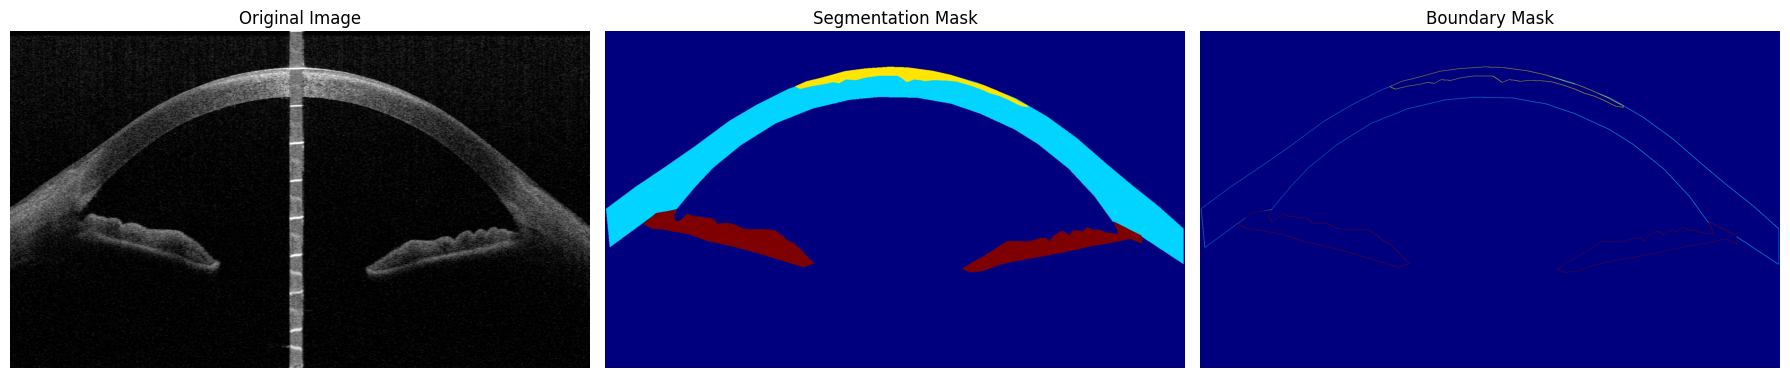

Image shape: (1000, 1723, 3)  |  Unique mask values: [0 1 2 3]


In [6]:
# Quick visualisation of a sample
if len(all_samples) > 0:
    _img_path, _ann_path, _is_full = all_samples[0]
    _img = cv2.imread(_img_path)
    _h, _w = _img.shape[:2]
    _mask = parse_labelme_json(_ann_path, _h, _w, include_iris=INCLUDE_IRIS)
    _bnd  = make_boundary_mask(_mask)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].imshow(cv2.cvtColor(_img, cv2.COLOR_BGR2RGB)); axes[0].set_title("Original Image")
    axes[1].imshow(_mask, cmap="jet", vmin=0, vmax=NUM_CLASSES-1); axes[1].set_title("Segmentation Mask")
    axes[2].imshow(_bnd, cmap="jet", vmin=0, vmax=NUM_CLASSES-1); axes[2].set_title("Boundary Mask")
    for ax in axes: ax.axis("off")
    plt.tight_layout(); plt.show()
    print(f"Image shape: {_img.shape}  |  Unique mask values: {np.unique(_mask)}")

## 3 — PyTorch Dataset & Augmentations

In [7]:
class AIDKDataset(Dataset):
    """AIDK Keratitis AS-OCT dataset for ScLNet training."""

    def __init__(self, samples, img_size=512, include_iris=False,
                 transform=None, boundary_thickness=2):
        self.samples = samples
        self.img_size = img_size
        self.include_iris = include_iris
        self.transform = transform
        self.boundary_thickness = boundary_thickness

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, ann_path, is_full = self.samples[idx]

        # Load image
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        h, w = image.shape[:2]

        # Parse annotation → segmentation mask
        seg_mask = parse_labelme_json(ann_path, h, w,
                                     include_iris=(self.include_iris and is_full))

        # Resize
        image    = cv2.resize(image, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_LINEAR)
        seg_mask = cv2.resize(seg_mask, (self.img_size, self.img_size),
                              interpolation=cv2.INTER_NEAREST)

        # Apply augmentations
        if self.transform:
            augmented = self.transform(image=image, mask=seg_mask)
            image    = augmented["image"]
            seg_mask = augmented["mask"]

        # Derive boundary mask from (augmented) segmentation mask
        if isinstance(seg_mask, torch.Tensor):
            seg_np = seg_mask.numpy()
        else:
            seg_np = seg_mask
        boundary_mask = make_boundary_mask(seg_np.astype(np.uint8),
                                          self.boundary_thickness)

        # Convert to tensors
        if not isinstance(image, torch.Tensor):
            image = torch.from_numpy(image.transpose(2, 0, 1)).float() / 255.0
        else:
            image = image.float() / 255.0 if image.max() > 1 else image.float()

        seg_mask = torch.from_numpy(seg_np).long()
        boundary_mask = torch.from_numpy(boundary_mask).long()

        return image, seg_mask, boundary_mask

In [8]:
# Augmentations matching the ScLNet paper (updated for albumentations v2.x)
train_transform = A.Compose([
    A.VerticalFlip(p=0.5),
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},  # +/-10% translation
        scale=(0.9, 1.1),           # scale 0.9-1.1
        rotate=(-10, 10),           # +/-10 degrees
        border_mode=cv2.BORDER_CONSTANT,
        fill=0,
        fill_mask=0,
        p=0.7,
    ),
    A.GaussNoise(std_range=(0.009, 0.02), p=0.3),
    A.RandomBrightnessContrast(brightness_limit=0.1, contrast_limit=0.1, p=0.3),
])

val_transform = None  # No augmentation for validation/test

In [9]:
# Train / Val / Test split
train_val_samples, test_samples = train_test_split(
    all_samples, test_size=TEST_SPLIT, random_state=SEED
)
train_samples, val_samples = train_test_split(
    train_val_samples, test_size=VAL_SPLIT / (1 - TEST_SPLIT), random_state=SEED
)

print(f"Train: {len(train_samples)} | Val: {len(val_samples)} | Test: {len(test_samples)}")

train_ds = AIDKDataset(train_samples, IMG_SIZE, INCLUDE_IRIS, train_transform)
val_ds   = AIDKDataset(val_samples,   IMG_SIZE, INCLUDE_IRIS, val_transform)
test_ds  = AIDKDataset(test_samples,  IMG_SIZE, INCLUDE_IRIS, val_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=1, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

Train: 537 | Val: 154 | Test: 77


## 4 — Model Architecture: ScLNet in PyTorch

Faithful reimplementation based on the paper description:
- Encoder with ResNet-34 backbone + feature subtraction
- Multi-scale input at 4 resolutions merged via DAC blocks
- Dual decoder: segmentation + boundary detection
- Skip connections between decoders

In [10]:
# ──────────────────────────────────────────────────────────────
# Building blocks
# ──────────────────────────────────────────────────────────────

class ResBlock(nn.Module):
    """Residual block: 1×1 conv shortcut + two 3×3 convs (Fig. 4 in paper)."""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.relu   = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 1, stride, bias=False),
            nn.BatchNorm2d(out_ch),
        ) if (in_ch != out_ch or stride != 1) else nn.Identity()

    def forward(self, x):
        identity = self.shortcut(x)
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class DACBlock(nn.Module):
    """Dense Atrous Convolution block (Fig. 6 in paper).
    Four cascaded branches with dilation rates [1, 3, 5] and 1×1 convs."""
    def __init__(self, channels):
        super().__init__()
        self.branch1 = nn.Sequential(
            nn.Conv2d(channels, channels, 3, padding=1, dilation=1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
        )
        self.branch2 = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=3, dilation=3, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
        )
        self.branch3 = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=3, dilation=3, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
            nn.Conv2d(channels, channels, 3, padding=5, dilation=5, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
        )
        self.branch4 = nn.Sequential(
            nn.Conv2d(channels, channels, 1, bias=False),
            nn.BatchNorm2d(channels), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x + b1)
        b3 = self.branch3(x + b1 + b2)
        b4 = self.branch4(x + b1 + b2 + b3)
        return x + b1 + b2 + b3 + b4

In [11]:
# ──────────────────────────────────────────────────────────────
# Encoder with multi-scale input + DAC context coding
# ──────────────────────────────────────────────────────────────

class ScLNetEncoder(nn.Module):
    """Multi-scale input encoder with ResBlock backbone + DAC + feature subtraction."""

    def __init__(self, in_channels=3):
        super().__init__()
        # Channel widths per encoder stage (ResNet-34-like)
        self.channels = [64, 128, 256, 512, 512]
        n_blocks      = [3,  4,   6,   3,   3]

        # Initial conv for full-resolution input
        self.stem = nn.Sequential(
            nn.Conv2d(in_channels, 64, 7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(inplace=True),
            nn.MaxPool2d(3, stride=2, padding=1),
        )

        # Multi-scale input adapters (½, ¼, ⅛ resolution inputs)
        self.scale_adapters = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_channels, self.channels[i], 3, padding=1, bias=False),
                nn.BatchNorm2d(self.channels[i]), nn.ReLU(inplace=True),
            ) for i in range(1, 4)  # For stages 1, 2, 3
        ])

        # DAC context coding blocks (one per stage that receives multi-scale input)
        self.dac_blocks = nn.ModuleList([
            DACBlock(self.channels[i]) for i in range(1, 4)
        ])

        # Encoder stages (stacked ResBlocks)
        self.stages = nn.ModuleList()
        in_ch = 64
        for i, (out_ch, n) in enumerate(zip(self.channels, n_blocks)):
            blocks = []
            for j in range(n):
                stride = 2 if (j == 0 and i > 0) else 1
                blocks.append(ResBlock(in_ch if j == 0 else out_ch, out_ch, stride))
            self.stages.append(nn.Sequential(*blocks))
            in_ch = out_ch

        # Conv layers parallel to ResBlocks for subtraction (boundary emphasis)
        self.conv_parallel = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(ch, ch, 3, padding=1, bias=False),
                nn.BatchNorm2d(ch), nn.ReLU(inplace=True),
            ) for ch in self.channels
        ])

    def forward(self, x):
        # Generate multi-scale inputs
        scales = [x]  # scale 0 = original
        for s in range(1, 4):
            scales.append(F.avg_pool2d(x, kernel_size=2**s, stride=2**s))

        # Stage 0: stem
        f0 = self.stem(x)              # (B, 64, H/4, W/4)
        f0 = self.stages[0](f0)        # ResBlocks stage 0

        seg_features = [f0]    # For segmentation decoder
        bnd_features = [f0]    # For boundary decoder

        prev_feat = f0
        for i in range(1, 5):
            f_res = self.stages[i](prev_feat)

            # Multi-scale input injection + DAC for stages 1-3
            if i <= 3:
                scale_feat = self.scale_adapters[i - 1](scales[i])
                # Align spatial dims
                if scale_feat.shape[2:] != f_res.shape[2:]:
                    scale_feat = F.interpolate(scale_feat, size=f_res.shape[2:],
                                              mode="bilinear", align_corners=False)
                f_res = f_res + scale_feat
                f_res = self.dac_blocks[i - 1](f_res)

            # Parallel conv + subtraction → boundary features
            f_conv = self.conv_parallel[i](f_res)
            f_boundary = f_res - f_conv  # Feature subtraction (Sec. 3.1 A)

            seg_features.append(f_res)
            bnd_features.append(f_boundary)
            prev_feat = f_res

        return seg_features, bnd_features  # Each list has 5 levels

In [12]:
# ──────────────────────────────────────────────────────────────
# Decoders
# ──────────────────────────────────────────────────────────────

class DecoderBlock(nn.Module):
    """Single decoder stage: upsample → concat skip(s) → ResBlocks."""
    def __init__(self, in_ch, skip_ch, out_ch, extra_skip_ch=0):
        super().__init__()
        self.up = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        total_in = in_ch + skip_ch + extra_skip_ch
        self.block = nn.Sequential(
            ResBlock(total_in, out_ch),
            ResBlock(out_ch, out_ch),
        )

    def forward(self, x, skip, extra_skip=None):
        x = self.up(x)
        # Align spatial dims if needed
        if x.shape[2:] != skip.shape[2:]:
            x = F.interpolate(x, size=skip.shape[2:], mode="bilinear",
                              align_corners=False)
        parts = [x, skip]
        if extra_skip is not None:
            if extra_skip.shape[2:] != skip.shape[2:]:
                extra_skip = F.interpolate(extra_skip, size=skip.shape[2:],
                                          mode="bilinear", align_corners=False)
            parts.append(extra_skip)
        return self.block(torch.cat(parts, dim=1))


class SegmentationDecoder(nn.Module):
    """Segmentation decoder with skip connections from encoder AND boundary decoder."""
    def __init__(self, enc_channels, num_classes):
        super().__init__()
        ch = enc_channels  # [64, 128, 256, 512, 512]
        # Decoder stages (deepest → shallowest)
        # Each receives: upsampled feature + encoder skip + boundary decoder skip
        self.dec4 = DecoderBlock(ch[4], ch[3], ch[3], extra_skip_ch=ch[3])
        self.dec3 = DecoderBlock(ch[3], ch[2], ch[2], extra_skip_ch=ch[2])
        self.dec2 = DecoderBlock(ch[2], ch[1], ch[1], extra_skip_ch=ch[1])
        self.dec1 = DecoderBlock(ch[1], ch[0], ch[0], extra_skip_ch=ch[0])

        self.final_up = nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False)
        self.head = nn.Conv2d(ch[0], num_classes, 1)

    def forward(self, seg_features, bnd_dec_features):
        # seg_features[0..4]: encoder skip connections (shallow→deep)
        # bnd_dec_features[0..3]: boundary decoder intermediate features
        d4 = self.dec4(seg_features[4], seg_features[3], bnd_dec_features[3])
        d3 = self.dec3(d4, seg_features[2], bnd_dec_features[2])
        d2 = self.dec2(d3, seg_features[1], bnd_dec_features[1])
        d1 = self.dec1(d2, seg_features[0], bnd_dec_features[0])

        out = self.final_up(d1)
        return self.head(out)


class BoundaryDecoder(nn.Module):
    """Boundary detection decoder (auxiliary task)."""
    def __init__(self, enc_channels, num_classes):
        super().__init__()
        ch = enc_channels
        self.dec4 = DecoderBlock(ch[4], ch[3], ch[3])
        self.dec3 = DecoderBlock(ch[3], ch[2], ch[2])
        self.dec2 = DecoderBlock(ch[2], ch[1], ch[1])
        self.dec1 = DecoderBlock(ch[1], ch[0], ch[0])

        self.final_up = nn.Upsample(scale_factor=4, mode="bilinear", align_corners=False)
        self.head = nn.Conv2d(ch[0], num_classes, 1)

    def forward(self, bnd_features):
        d4 = self.dec4(bnd_features[4], bnd_features[3])
        d3 = self.dec3(d4, bnd_features[2])
        d2 = self.dec2(d3, bnd_features[1])
        d1 = self.dec1(d2, bnd_features[0])

        intermediate = [d1, d2, d3, d4]  # For seg decoder skip connections
        out = self.final_up(d1)
        return self.head(out), intermediate

In [13]:
# ──────────────────────────────────────────────────────────────
# Full ScLNet
# ──────────────────────────────────────────────────────────────

class ScLNet(nn.Module):
    """ScLNet: multi-task segmentation + boundary detection network.

    Adapted from Cao et al. (Heliyon, 2024) for keratitis AS-OCT segmentation.
    """

    def __init__(self, in_channels=3, num_classes=3):
        super().__init__()
        self.encoder = ScLNetEncoder(in_channels)
        enc_ch = self.encoder.channels  # [64, 128, 256, 512, 512]
        self.boundary_decoder = BoundaryDecoder(enc_ch, num_classes)
        self.seg_decoder      = SegmentationDecoder(enc_ch, num_classes)

    def forward(self, x):
        seg_features, bnd_features = self.encoder(x)
        bnd_out, bnd_intermediates = self.boundary_decoder(bnd_features)
        seg_out = self.seg_decoder(seg_features, bnd_intermediates)
        return seg_out, bnd_out


# Quick test
_model = ScLNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
_dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
with torch.no_grad():
    _seg, _bnd = _model(_dummy)
print(f"Seg output: {_seg.shape}  |  Bnd output: {_bnd.shape}")

total_params = sum(p.numel() for p in _model.parameters())
print(f"Total parameters: {total_params / 1e6:.2f} M")
del _model, _dummy, _seg, _bnd
torch.cuda.empty_cache()

Seg output: torch.Size([1, 4, 512, 512])  |  Bnd output: torch.Size([1, 4, 512, 512])
Total parameters: 92.61 M


## 5 — Loss Functions

The paper uses **log-Dice loss** for both tasks, combined as:  
`LOSS_total = λ × LOSS_boundary + (1 − λ) × LOSS_segmentation`  
with λ = 0.4.

In [14]:
class LogDiceLoss(nn.Module):
    """Log-Dice loss for multi-class segmentation.

    Applies softmax then computes per-class Dice, takes the negative log,
    and averages across classes. Handles class imbalance well.
    """
    def __init__(self, num_classes, smooth=1.0):
        super().__init__()
        self.num_classes = num_classes
        self.smooth = smooth

    def forward(self, logits, targets):
        probs = F.softmax(logits, dim=1)  # (B, C, H, W)

        # One-hot encode targets
        targets_oh = F.one_hot(targets, self.num_classes)  # (B, H, W, C)
        targets_oh = targets_oh.permute(0, 3, 1, 2).float()  # (B, C, H, W)

        dice_per_class = []
        for c in range(self.num_classes):
            p = probs[:, c].reshape(-1)
            g = targets_oh[:, c].reshape(-1)
            intersection = (p * g).sum()
            dice = (2.0 * intersection + self.smooth) / \
                   (p.pow(2).sum() + g.pow(2).sum() + self.smooth)
            dice_per_class.append(dice)

        dice_avg = torch.stack(dice_per_class).mean()
        # Log-Dice loss (Eq. 3 in paper: use 1-Dice, then take -log)
        return -torch.log(dice_avg + 1e-8)


class ScLNetLoss(nn.Module):
    """Combined segmentation + boundary loss (Eq. 2 in paper)."""
    def __init__(self, num_classes, lam=0.4):
        super().__init__()
        self.seg_loss = LogDiceLoss(num_classes)
        self.bnd_loss = LogDiceLoss(num_classes)
        self.lam = lam

    def forward(self, seg_logits, bnd_logits, seg_targets, bnd_targets):
        l_seg = self.seg_loss(seg_logits, seg_targets)
        l_bnd = self.bnd_loss(bnd_logits, bnd_targets)
        return self.lam * l_bnd + (1 - self.lam) * l_seg, l_seg, l_bnd

## 6 — Evaluation Metrics

Matching the paper: **DSC**, **IoU**, **MCC**, **Precision**, **Hausdorff Distance**.

In [15]:
def compute_metrics(pred: np.ndarray, gt: np.ndarray, num_classes: int):
    """Compute per-class DSC, IoU, MCC, Precision, HD.

    Args:
        pred: (H, W) predicted class indices
        gt:   (H, W) ground truth class indices
        num_classes: total number of classes

    Returns:
        dict mapping class_id → {DSC, IoU, MCC, Precision, HD}
    """
    results = {}
    for c in range(1, num_classes):  # Skip background
        p = (pred == c).astype(np.float32)
        g = (gt == c).astype(np.float32)

        tp = (p * g).sum()
        fp = (p * (1 - g)).sum()
        fn = ((1 - p) * g).sum()
        tn = ((1 - p) * (1 - g)).sum()

        # DSC
        dsc = (2 * tp) / (2 * tp + fp + fn + 1e-8)

        # IoU
        iou = tp / (tp + fp + fn + 1e-8)

        # MCC
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn) + 1e-8)
        mcc = (tp * tn - fp * fn) / denom

        # Precision
        precision = tp / (tp + fp + 1e-8)

        # Hausdorff Distance
        p_pts = np.argwhere(p > 0)
        g_pts = np.argwhere(g > 0)
        if len(p_pts) > 0 and len(g_pts) > 0:
            hd = max(directed_hausdorff(p_pts, g_pts)[0],
                     directed_hausdorff(g_pts, p_pts)[0])
        elif len(p_pts) == 0 and len(g_pts) == 0:
            hd = 0.0
        else:
            hd = float("inf")

        results[c] = {
            "DSC": float(dsc), "IoU": float(iou), "MCC": float(mcc),
            "Precision": float(precision), "HD": float(hd),
        }
    return results


CLASS_NAMES = {1: "Cornea", 2: "Lesion"}
if INCLUDE_IRIS:
    CLASS_NAMES[3] = "Iris"

## 7 — Training Loop

In [16]:
model     = ScLNet(in_channels=3, num_classes=NUM_CLASSES).to(DEVICE)
if torch.cuda.device_count() > 1:
    print(f"Using {torch.cuda.device_count()} GPUs via DataParallel")
    model = nn.DataParallel(model)

criterion = ScLNetLoss(NUM_CLASSES, lam=LAMBDA_BOUNDARY)
optimizer = optim.SGD(model.parameters(), lr=INIT_LR, momentum=0.9, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=LR_STEP, gamma=LR_GAMMA)

# Mixed precision: cuts GPU memory ~40-50% — should prevent the epoch-67 OOM crash
scaler = torch.cuda.amp.GradScaler()
print("Mixed precision (AMP) enabled")

Using 2 GPUs via DataParallel
Mixed precision (AMP) enabled


/tmp/ipykernel_55/4023859698.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [17]:
def train_one_epoch(model, loader, criterion, optimizer, device, scaler):
    model.train()
    running_loss = 0.0
    for images, seg_masks, bnd_masks in tqdm(loader, desc="Train", leave=False):
        images   = images.to(device)
        seg_masks = seg_masks.to(device)
        bnd_masks = bnd_masks.to(device)

        # Mixed precision forward pass
        with torch.cuda.amp.autocast():
            seg_out, bnd_out = model(images)

            # Ensure output matches target spatial size
            if seg_out.shape[2:] != seg_masks.shape[1:]:
                seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                       mode="bilinear", align_corners=False)
                bnd_out = F.interpolate(bnd_out, size=bnd_masks.shape[1:],
                                       mode="bilinear", align_corners=False)

            loss, l_seg, l_bnd = criterion(seg_out, bnd_out, seg_masks, bnd_masks)

        optimizer.zero_grad()
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * images.size(0)

    return running_loss / len(loader.dataset)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes):
    model.eval()
    running_loss = 0.0
    all_metrics = {c: {"DSC": [], "IoU": []} for c in range(1, num_classes)}

    for images, seg_masks, bnd_masks in tqdm(loader, desc="Val", leave=False):
        images    = images.to(device)
        seg_masks = seg_masks.to(device)
        bnd_masks = bnd_masks.to(device)

        with torch.cuda.amp.autocast():
            seg_out, bnd_out = model(images)
            if seg_out.shape[2:] != seg_masks.shape[1:]:
                seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                       mode="bilinear", align_corners=False)
                bnd_out = F.interpolate(bnd_out, size=bnd_masks.shape[1:],
                                       mode="bilinear", align_corners=False)

            loss, _, _ = criterion(seg_out, bnd_out, seg_masks, bnd_masks)

        running_loss += loss.item() * images.size(0)

        preds = seg_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.cpu().numpy()
        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], num_classes)
            for c in m:
                all_metrics[c]["DSC"].append(m[c]["DSC"])
                all_metrics[c]["IoU"].append(m[c]["IoU"])

    avg_loss = running_loss / len(loader.dataset)
    summary = {}
    for c in all_metrics:
        summary[c] = {
            "DSC": np.mean(all_metrics[c]["DSC"]),
            "IoU": np.mean(all_metrics[c]["IoU"]),
        }
    return avg_loss, summary

In [ ]:
# -- Main training loop --
best_val_loss = float("inf")
epochs_no_improve = 0
history = {"train_loss": [], "val_loss": [], "val_dsc": []}

SAVE_PATH = "sclnet_keratitis_best.pth"

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}  |  LR: {scheduler.get_last_lr()[0]:.6f}")

    train_loss = train_one_epoch(model, train_loader, criterion, optimizer, DEVICE, scaler)
    val_loss, val_metrics = validate(model, val_loader, criterion, DEVICE, NUM_CLASSES)
    scheduler.step()

    # Average DSC across foreground classes
    avg_dsc = np.mean([val_metrics[c]["DSC"] for c in val_metrics])

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_dsc"].append(avg_dsc)

    metric_str = "  ".join(
        f"{CLASS_NAMES.get(c, c)}: DSC={val_metrics[c]['DSC']:.4f} IoU={val_metrics[c]['IoU']:.4f}"
        for c in val_metrics
    )
    print(f"  Train Loss: {train_loss:.4f}  |  Val Loss: {val_loss:.4f}  |  Avg DSC: {avg_dsc:.4f}")
    print(f"  {metric_str}")

    # Checkpointing
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
        torch.save(state, SAVE_PATH)
        print(f"  >> Saved best model (val_loss={val_loss:.4f})")
    else:
        epochs_no_improve += 1

    # Early stopping
    if epochs_no_improve >= EARLY_STOP:
        print(f"\nEarly stopping after {EARLY_STOP} epochs without improvement.")
        break

print("\nTraining complete.")

In [ ]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history["train_loss"], label="Train Loss")
ax1.plot(history["val_loss"], label="Val Loss")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")
ax1.set_title("Training & Validation Loss"); ax1.legend()

ax2.plot(history["val_dsc"], label="Val DSC (avg)", color="green")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Dice Similarity Coefficient")
ax2.set_title("Validation DSC"); ax2.legend()

plt.tight_layout(); plt.show()

## 8 — Test Set Evaluation

In [20]:
# Load best model
SAVE_PATH = "/kaggle/input/models/ianxlee/sclnet-final/other/default/1/sclnet_keratitis_best.pth"
raw_model = model.module if hasattr(model, 'module') else model
raw_model.load_state_dict(torch.load(SAVE_PATH, map_location=DEVICE))
model.eval()

test_metrics_all = {c: {k: [] for k in ["DSC", "IoU", "MCC", "Precision", "HD"]}
                    for c in range(1, NUM_CLASSES)}

with torch.no_grad():
    for images, seg_masks, bnd_masks in tqdm(test_loader, desc="Testing"):
        images = images.to(DEVICE)
        seg_out, _ = model(images)
        if seg_out.shape[2:] != seg_masks.shape[1:]:
            seg_out = F.interpolate(seg_out, size=seg_masks.shape[1:],
                                   mode="bilinear", align_corners=False)
        preds = seg_out.argmax(dim=1).cpu().numpy()
        gts   = seg_masks.numpy()

        for i in range(preds.shape[0]):
            m = compute_metrics(preds[i], gts[i], NUM_CLASSES)
            for c in m:
                for k in m[c]:
                    test_metrics_all[c][k].append(m[c][k])

# Print results table
print("\n" + "="*80)
print("TEST SET RESULTS")
print("="*80)
print(f"{'Class':<12} {'DSC':>8} {'IoU':>8} {'MCC':>8} {'Precision':>10} {'HD':>10}")
print("-"*60)
for c in sorted(test_metrics_all.keys()):
    name = CLASS_NAMES.get(c, f"Class {c}")
    dsc  = np.mean(test_metrics_all[c]["DSC"])
    iou  = np.mean(test_metrics_all[c]["IoU"])
    mcc  = np.mean(test_metrics_all[c]["MCC"])
    prec = np.mean(test_metrics_all[c]["Precision"])
    hd   = np.mean([h for h in test_metrics_all[c]["HD"] if h != float("inf")])
    print(f"{name:<12} {dsc:>8.4f} {iou:>8.4f} {mcc:>8.4f} {prec:>10.4f} {hd:>10.2f}")
print("="*80)

Testing:   0%|          | 0/77 [00:00<?, ?it/s]


TEST SET RESULTS
Class             DSC      IoU      MCC  Precision         HD
------------------------------------------------------------
Cornea         0.9705   0.9428   0.9675     0.9658      16.35
Lesion         0.6713   0.6068   0.6721     0.6788       7.30
Iris           0.9288   0.8685   0.9269     0.9199      13.58


## 9 — Visualise Predictions

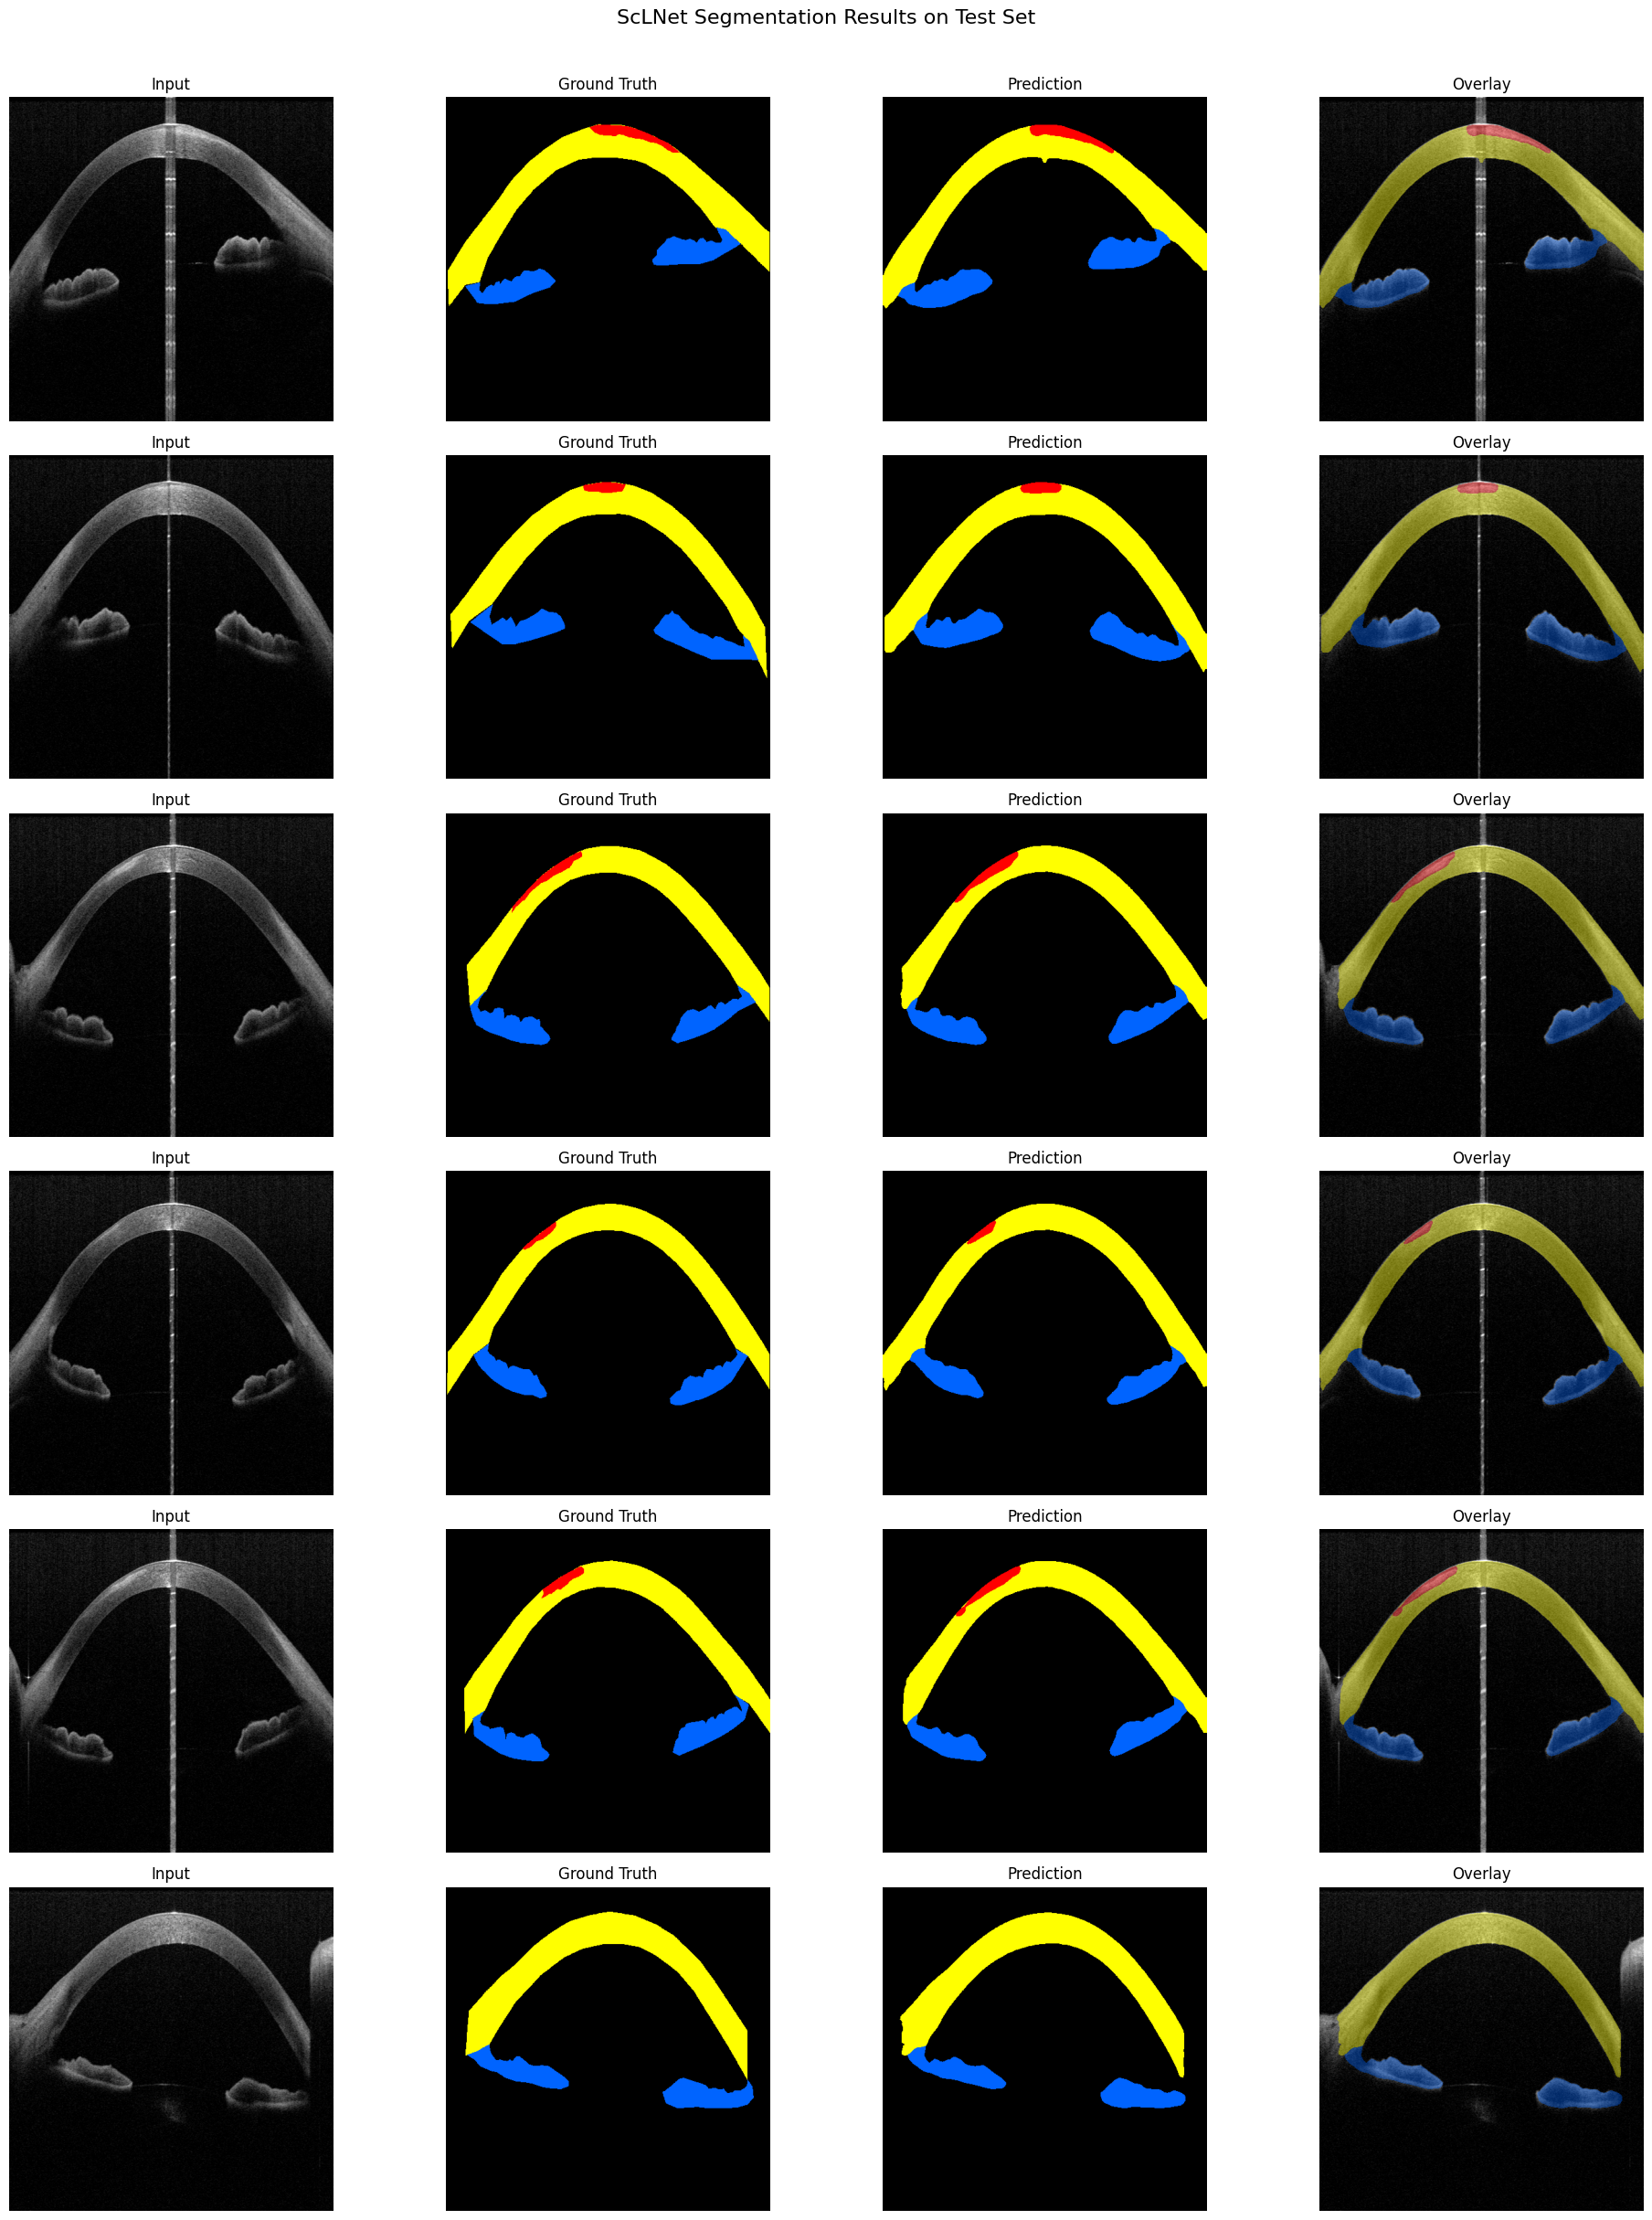

In [21]:
# Colour map for overlay: bg=black, cornea=yellow, lesion=red, iris=blue
COLORS = np.array([
    [0,   0,   0],    # 0: background
    [255, 255, 0],    # 1: cornea
    [255, 0,   0],    # 2: lesion
    [0,   100, 255],  # 3: iris
], dtype=np.uint8)


def mask_to_rgb(mask, alpha=0.4, image=None):
    """Convert class mask to RGB overlay."""
    rgb = COLORS[mask]
    if image is not None:
        img_rgb = (image * 255).astype(np.uint8) if image.max() <= 1 else image
        # Blend where mask > 0
        fg = mask > 0
        blended = img_rgb.copy()
        blended[fg] = (alpha * rgb[fg] + (1 - alpha) * img_rgb[fg]).astype(np.uint8)
        return blended
    return rgb


# Show N random test samples
N_VIS = 6
vis_indices = random.sample(range(len(test_ds)), min(N_VIS, len(test_ds)))

fig, axes = plt.subplots(len(vis_indices), 4, figsize=(20, 4 * len(vis_indices)))
if len(vis_indices) == 1:
    axes = axes[np.newaxis, :]

model.eval()
with torch.no_grad():
    for row, idx in enumerate(vis_indices):
        img_t, seg_gt, bnd_gt = test_ds[idx]
        seg_out, bnd_out = model(img_t.unsqueeze(0).to(DEVICE))
        if seg_out.shape[2:] != seg_gt.shape[:]:
            seg_out = F.interpolate(seg_out, size=seg_gt.shape[:],
                                   mode="bilinear", align_corners=False)
        pred = seg_out.argmax(dim=1)[0].cpu().numpy()
        gt   = seg_gt.numpy()
        img_np = img_t.permute(1, 2, 0).numpy()

        axes[row, 0].imshow(img_np);              axes[row, 0].set_title("Input")
        axes[row, 1].imshow(mask_to_rgb(gt));      axes[row, 1].set_title("Ground Truth")
        axes[row, 2].imshow(mask_to_rgb(pred));    axes[row, 2].set_title("Prediction")
        axes[row, 3].imshow(mask_to_rgb(pred, image=img_np))
        axes[row, 3].set_title("Overlay")
        for c in range(4):
            axes[row, c].axis("off")

plt.suptitle("ScLNet Segmentation Results on Test Set", fontsize=16, y=1.01)
plt.tight_layout(); plt.show()

## 10 — Save / Export Model

In [22]:
# Save full checkpoint with training info
state = model.module.state_dict() if hasattr(model, 'module') else model.state_dict()
torch.save({
    "model_state_dict": state,
    "optimizer_state_dict": optimizer.state_dict(),
    "num_classes": NUM_CLASSES,
    "img_size": IMG_SIZE,
    "history": history,
    "config": {
        "batch_size": BATCH_SIZE,
        "init_lr": INIT_LR,
        "lambda_boundary": LAMBDA_BOUNDARY,
        "include_iris": INCLUDE_IRIS,
        "use_subset": USE_SUBSET,
    }
}, "sclnet_keratitis_checkpoint.pth")

print("Checkpoint saved to sclnet_keratitis_checkpoint.pth")

NameError: name 'history' is not defined

---

## Notes & Tips

1. **GPU Memory:** With `BATCH_SIZE=2` and `IMG_SIZE=512`, the model requires
   roughly 6–8 GB of VRAM. Reduce `IMG_SIZE` to 384 or 256 if memory is tight.

2. **Class Imbalance:** Lesion regions are often small relative to the cornea and background.
   The log-Dice loss helps, but you can also experiment with Focal loss or
   class-weighted cross-entropy as alternatives.

3. **Full-frame vs Partial-frame:** Partial-frame images only show part of the anterior
   segment. If using `USE_SUBSET="both"`, the model learns from both types. You may
   get better results training separate models if the distributions are very different.

4. **Iris segmentation:** Set `INCLUDE_IRIS=True` and `USE_SUBSET="full"` to train
   a 4-class model (background, cornea, lesion, iris) on the 768 full-frame images.

5. **Pretrained weights:** The encoder could benefit from ImageNet pretraining.
   You can initialise the ResBlock stages from a pretrained ResNet-34.

6. **Original ScLNet repo:** The code at https://github.com/smallJude/ScLNet
   uses Keras/TF 1.x. This notebook reimplements the architecture in PyTorch
   based on the paper's description and figures.

### References

- Cao, Y. et al. *ScLNet: A cornea with scleral lens OCT layers segmentation dataset
  and new multi-task model.* Heliyon 10, e33911 (2024). doi:10.1016/j.heliyon.2024.e33911
- Sun, Y. et al. *An AS-OCT image dataset for deep learning-enabled segmentation and
  3D reconstruction for keratitis.* Scientific Data 11, 627 (2024). doi:10.1038/s41597-024-03464-0